In [1]:
!pip install duckdb pandas scikit-learn matplotlib seaborn pyarrow -q

import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()

con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

print("DuckDB Hugging Face bağlantısı başarılı!")

DuckDB Hugging Face bağlantısı başarılı!


In [3]:
query = """
WITH monthly_summary AS (
    SELECT
        client_hash_id,
        content_hash_id,
        count(distinct report_date) as active_days,
        sum(gsc_impressions) as total_impressions,
        sum(gsc_clicks) as total_clicks,
        round(sum(gsc_sum_position) * 1.0 / nullif(sum(gsc_impressions), 0), 1) as weighted_position,
        coalesce(sum(sessions_organic), 0) as total_organic_sessions,
        coalesce(sum(sessions_ai), 0) as total_ai_sessions,
        coalesce(sum(scroll_events), 0) as total_scroll_events
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/**/*.parquet')
    WHERE gsc_data_available = true
    GROUP BY client_hash_id, content_hash_id
    HAVING sum(gsc_impressions) >= 100 -- İstatistiki gürültüyü elemek için asgari hacim eşiği
)
SELECT
    client_hash_id,
    content_hash_id,
    active_days,
    total_impressions,
    total_clicks,
    round(total_clicks * 100.0 / nullif(total_impressions, 0), 2) as ctr,
    weighted_position,
    total_organic_sessions,
    total_ai_sessions,
    total_scroll_events,
    -- Hedef Değişken (Label):
    -- Pozisyonu 10 ile 30 arasında sıkışmış (Google 2. ve 3. sayfa) ve tıklama alamayan fırsat sayfaları = 1, diğerleri = 0
    CASE
        WHEN weighted_position BETWEEN 10.0 AND 30.0 AND total_clicks < 5 THEN 1
        ELSE 0
    END as refresh_opportunity
FROM monthly_summary
"""

print("Veri ambarından özellik matrisi çıkarılıyor...")
df_model = con.sql(query).df()

print(f"\nHazırlanan Veri Boyutu: {df_model.shape[0]} satır (benzersiz içerik), {df_model.shape[1]} sütun")
print("\nHedef Değişken (Refresh Opportunity) Dağılımı:")
print(df_model['refresh_opportunity'].value_counts(dropna=False))
print("\nOransal Dağılım (%):")
print(df_model['refresh_opportunity'].value_counts(normalize=True) * 100)

Veri ambarından özellik matrisi çıkarılıyor...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Hazırlanan Veri Boyutu: 101441 satır (benzersiz içerik), 11 sütun

Hedef Değişken (Refresh Opportunity) Dağılımı:
refresh_opportunity
0    77008
1    24433
Name: count, dtype: int64

Oransal Dağılım (%):
refresh_opportunity
0    75.914078
1    24.085922
Name: proportion, dtype: float64


Eğitim Kümesi: 93085 satır (33 müşteri)
Test Kümesi (Görülmemiş Müşteriler): 8356 satır (11 müşteri)

--- TEST SONUÇLARI (ROC AUC) ---
Heuristic Baseline:   0.5959
Logistic Regression:  0.6834
Random Forest:        0.6972


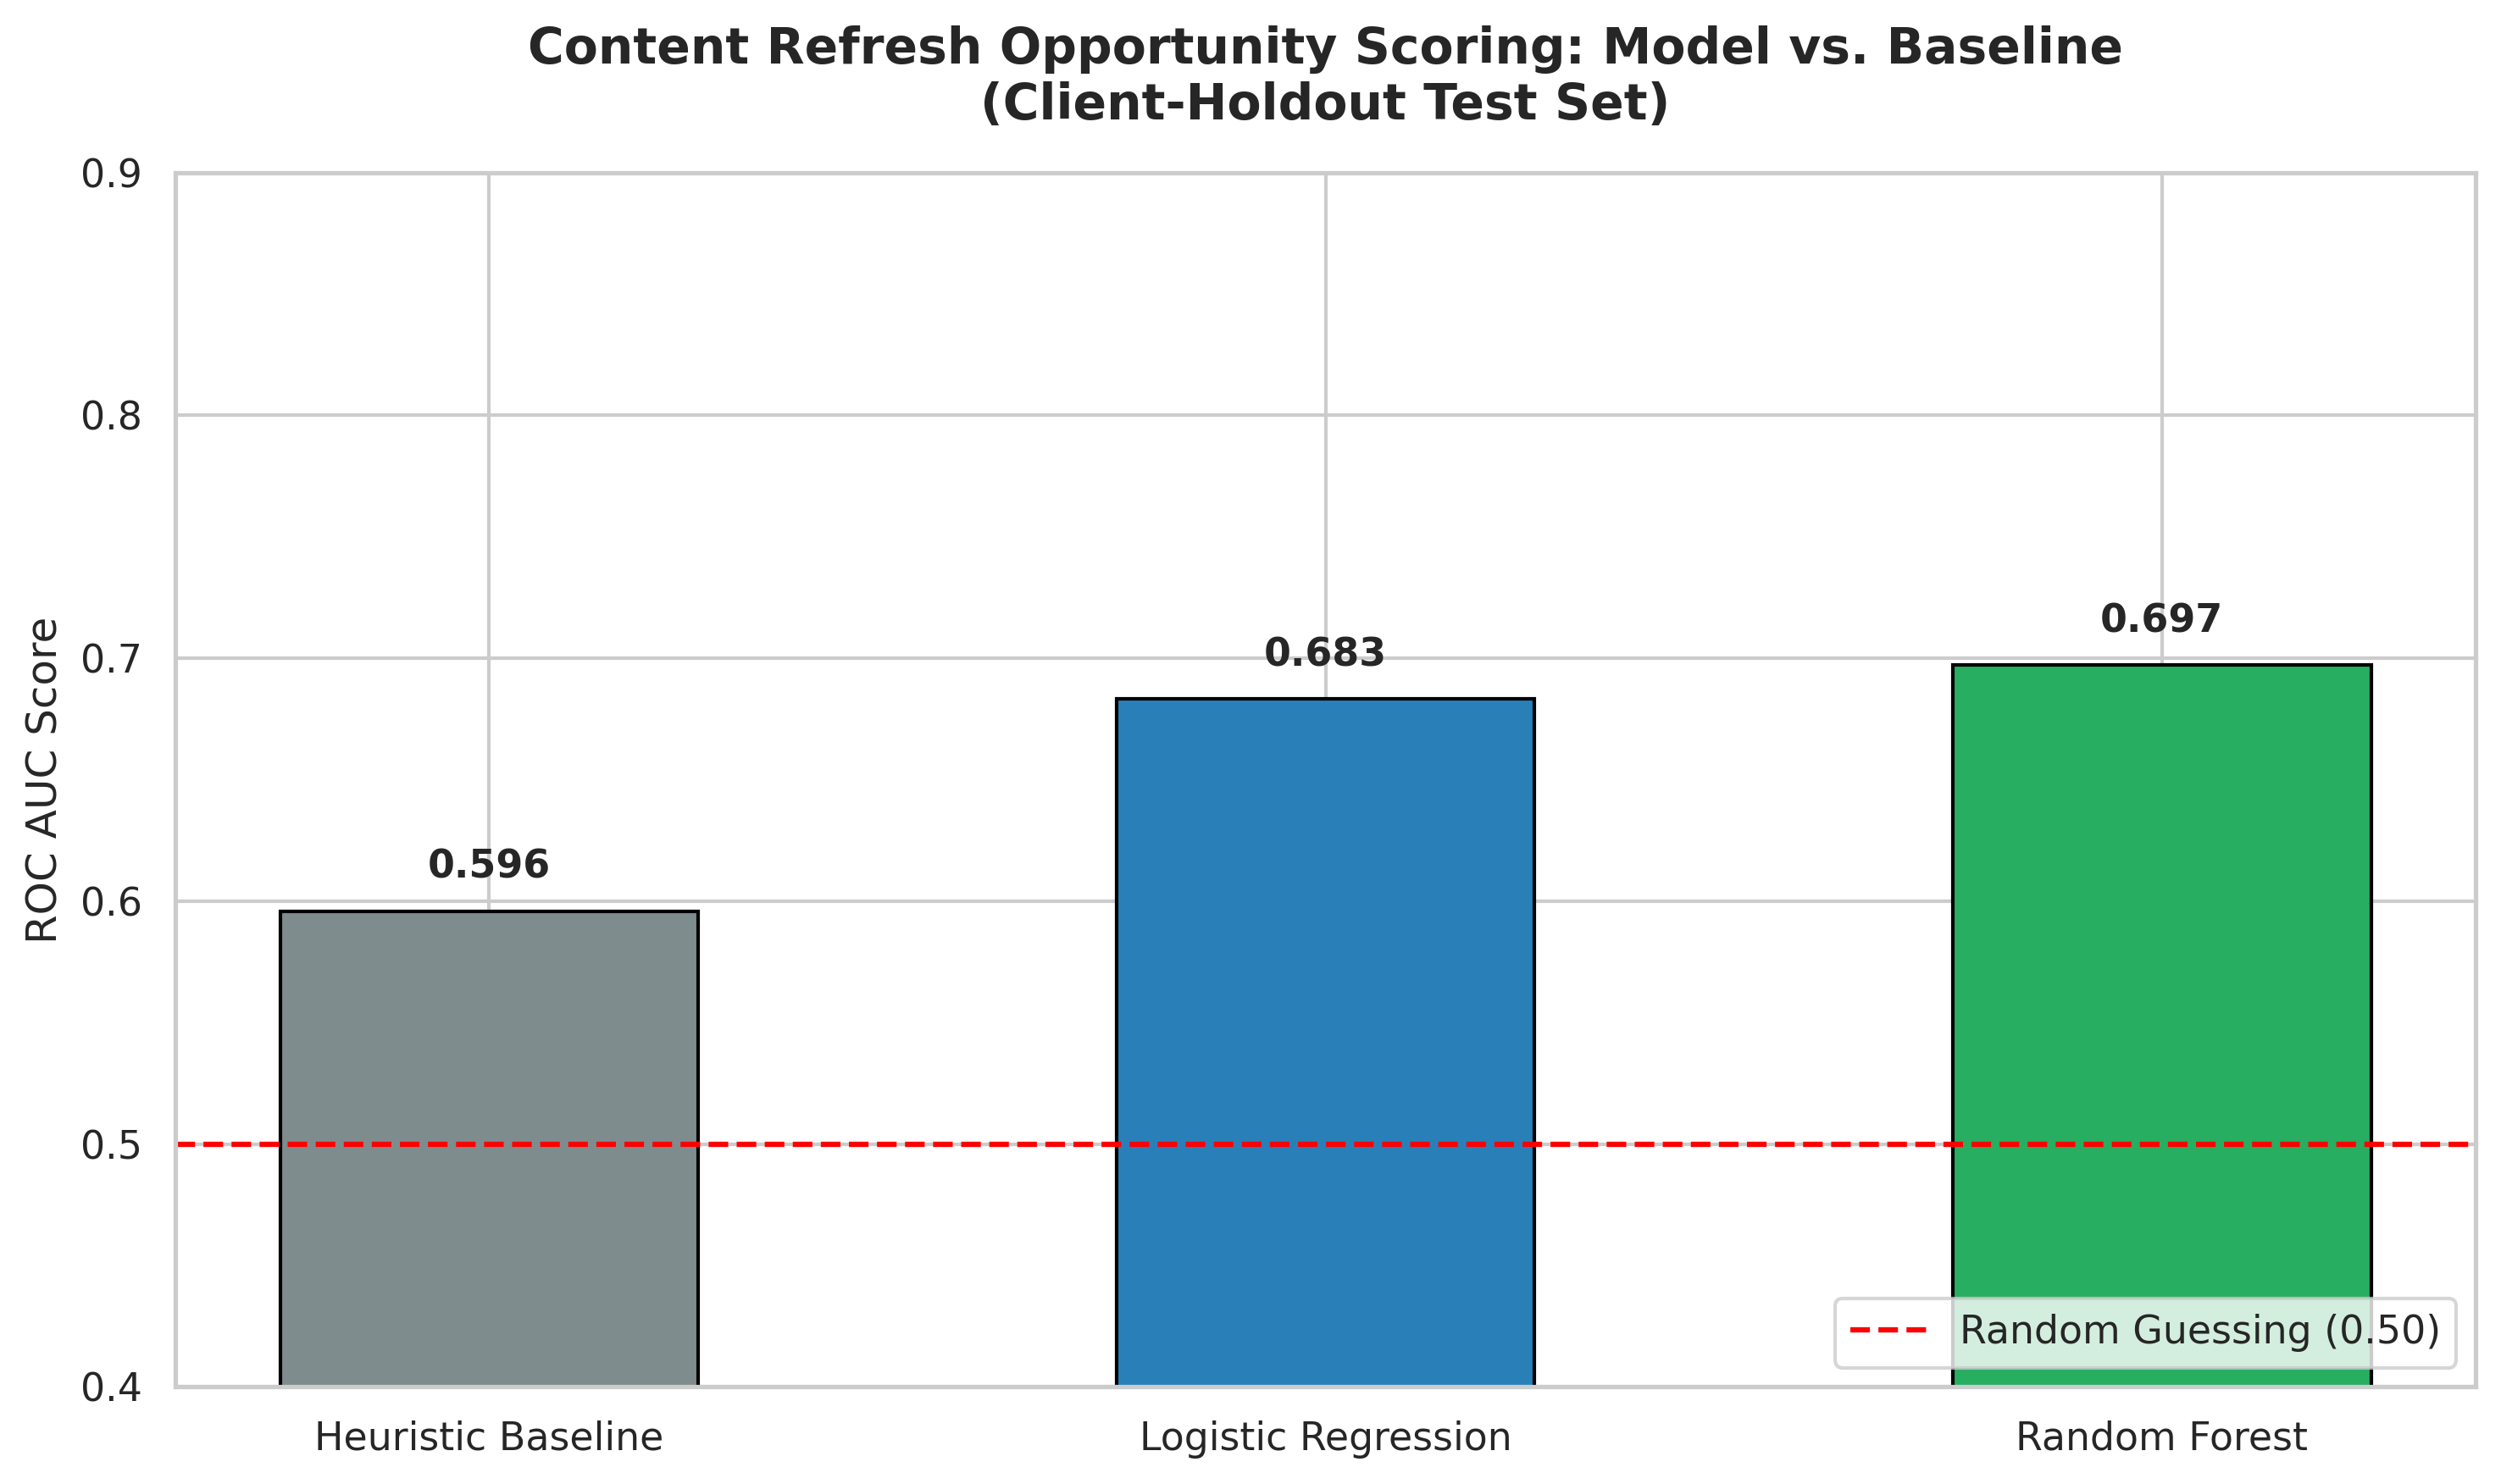

Grafik 'model_comparison.png' olarak başarıyla kaydedildi.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve


features = [
    'active_days',
    'total_impressions',
    'ctr',
    'total_organic_sessions',
    'total_ai_sessions',
    'total_scroll_events'
]

X = df_model[features].fillna(0)
y = df_model['refresh_opportunity']
groups = df_model['client_hash_id']


gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_clients = groups.iloc[train_idx].nunique()
test_clients = groups.iloc[test_idx].nunique()
print(f"Eğitim Kümesi: {len(X_train)} satır ({train_clients} müşteri)")
print(f"Test Kümesi (Görülmemiş Müşteriler): {len(X_test)} satır ({test_clients} müşteri)")


baseline_scores = np.log1p(X_test['total_impressions']) * (1.0 / (X_test['ctr'] + 0.1))

baseline_probs = (baseline_scores - baseline_scores.min()) / (baseline_scores.max() - baseline_scores.min())
auc_baseline = roc_auc_score(y_test, baseline_probs)


lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, lr_probs)


rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, rf_probs)

print("\n--- TEST SONUÇLARI (ROC AUC) ---")
print(f"Heuristic Baseline:   {auc_baseline:.4f}")
print(f"Logistic Regression:  {auc_lr:.4f}")
print(f"Random Forest:        {auc_rf:.4f}")


plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style="whitegrid")

models = ['Heuristic Baseline', 'Logistic Regression', 'Random Forest']
auc_scores = [auc_baseline, auc_lr, auc_rf]
colors = ['#7f8c8d', '#2980b9', '#27ae60']

bars = plt.bar(models, auc_scores, color=colors, width=0.5, edgecolor='black', linewidth=1)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random Guessing (0.50)')

plt.title('Content Refresh Opportunity Scoring: Model vs. Baseline\n(Client-Holdout Test Set)', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('ROC AUC Score', fontsize=12)
plt.ylim(0.4, 0.9)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

print("Grafik 'model_comparison.png' olarak başarıyla kaydedildi.")

/tmp/ipykernel_509/3031510306.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='mako')


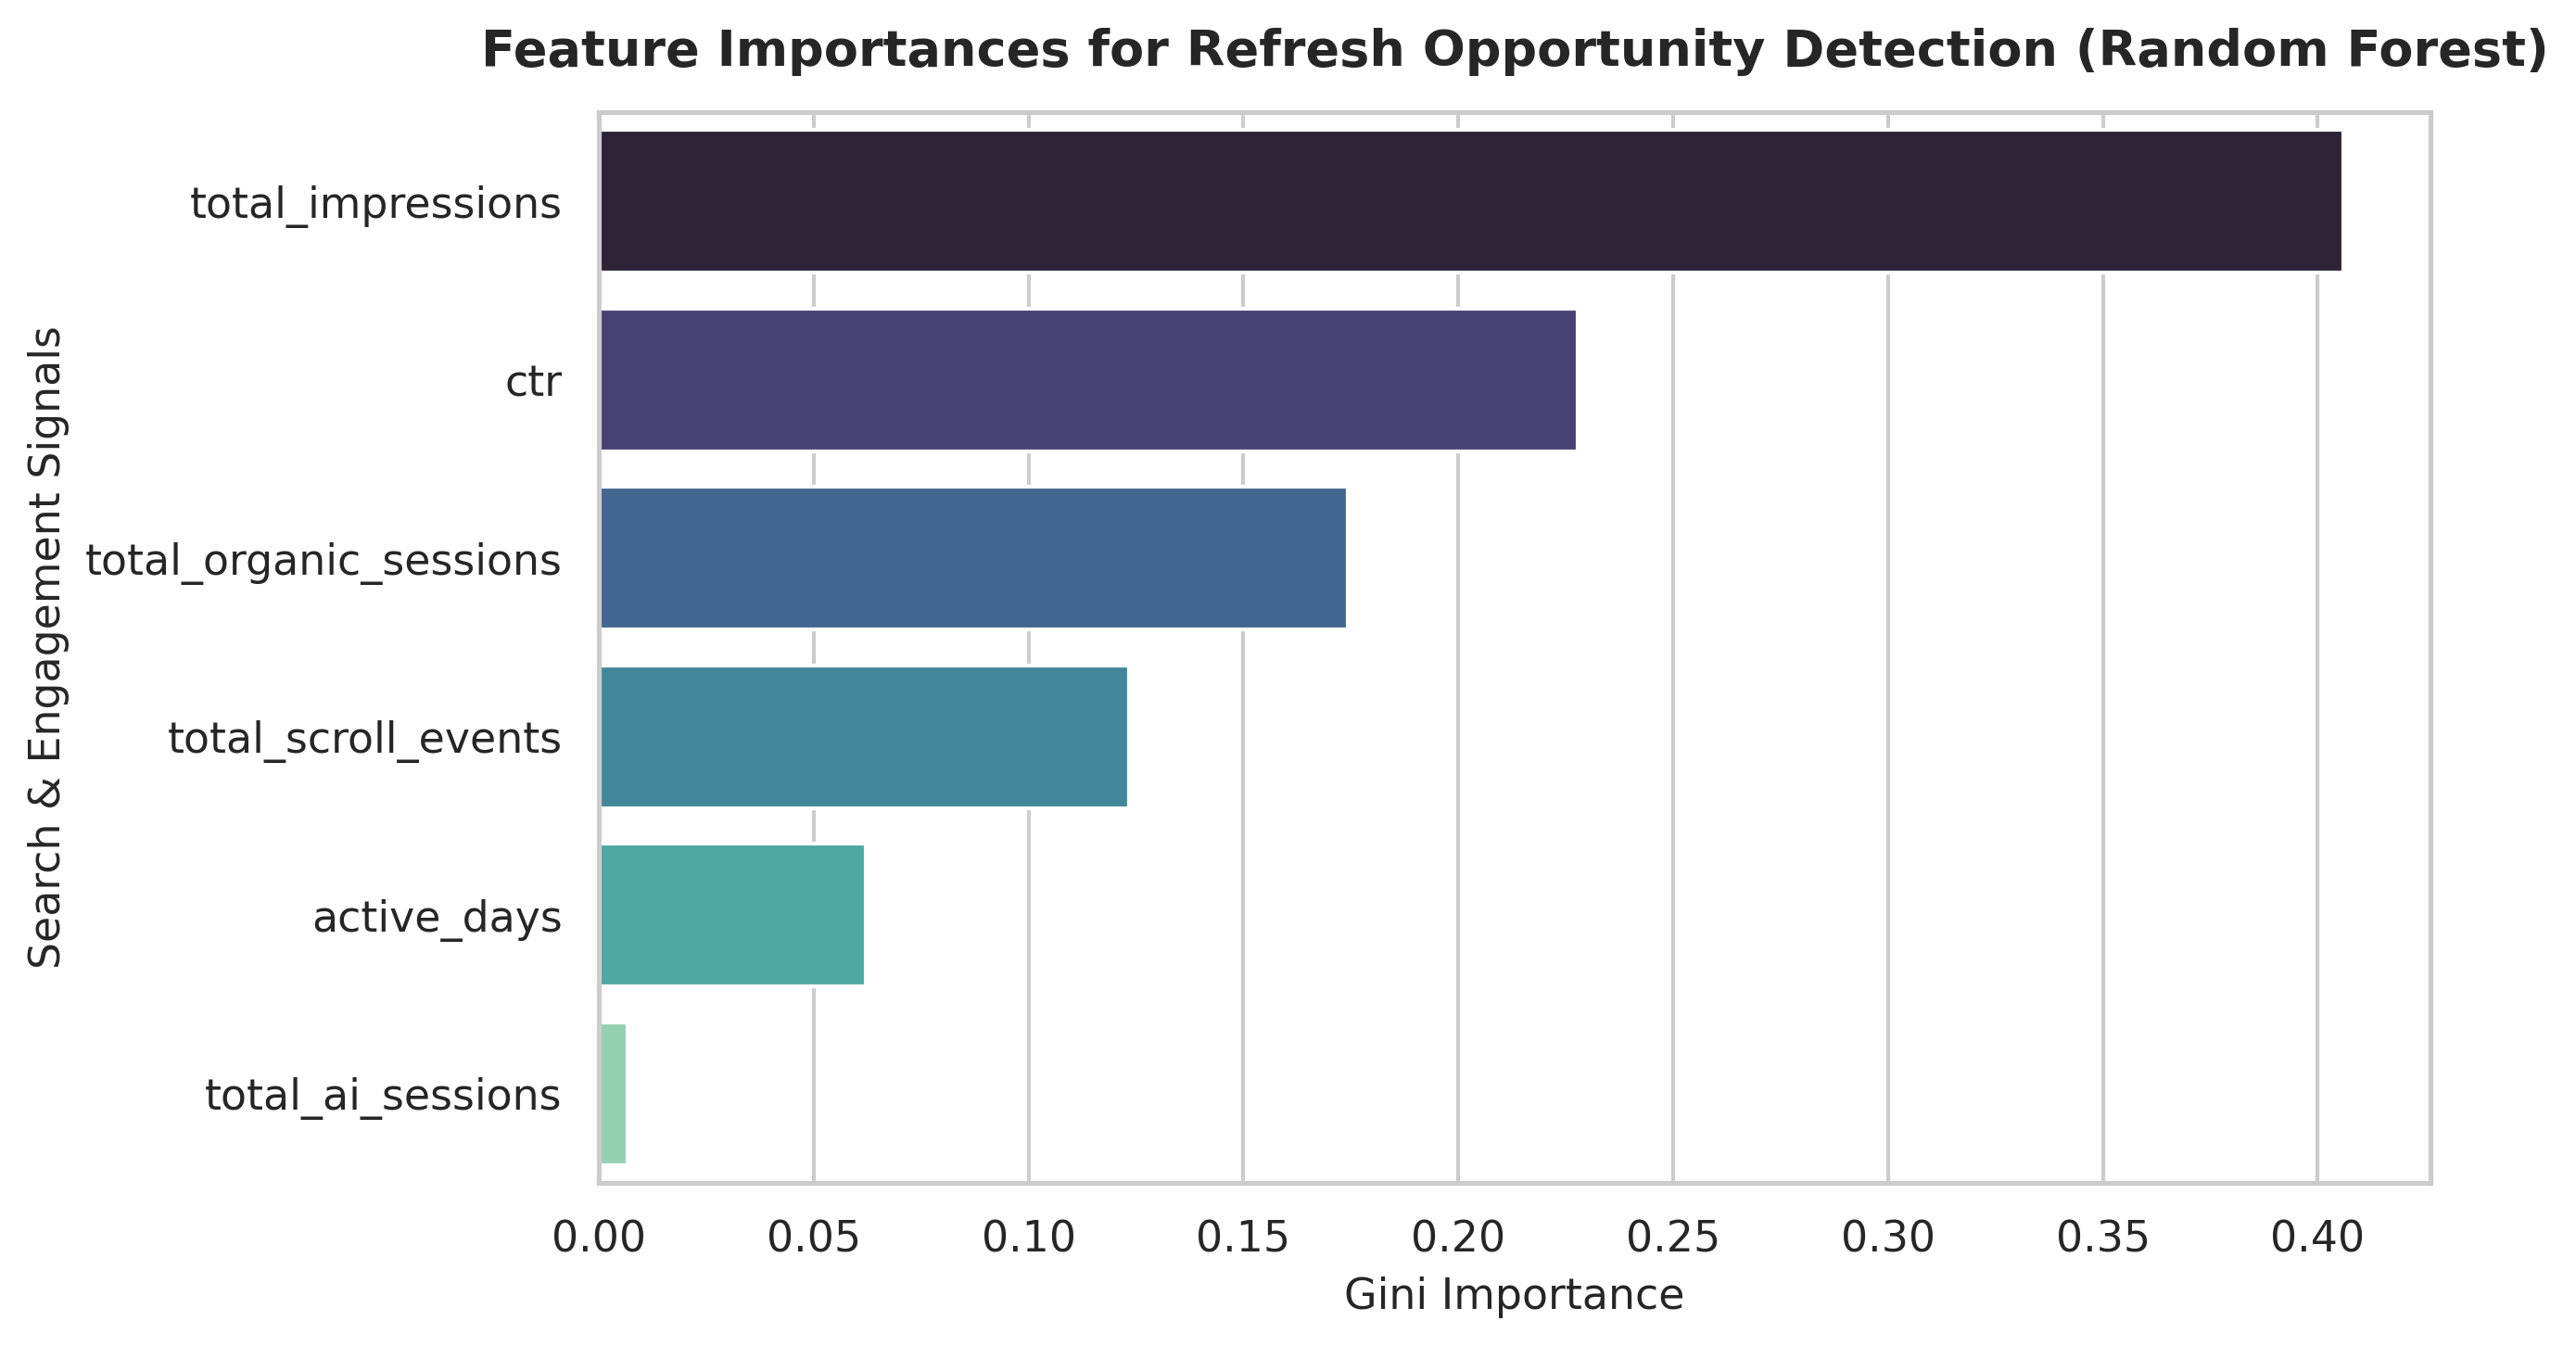


--- Öznitelik Önem Sıralaması ---
                  Feature  Importance
1       total_impressions    0.405927
2                     ctr    0.227737
3  total_organic_sessions    0.174244
5     total_scroll_events    0.123287
0             active_days    0.062059
4       total_ai_sessions    0.006745


In [5]:

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5), dpi=300)
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='mako')
plt.title('Feature Importances for Refresh Opportunity Detection (Random Forest)', fontsize=13, pad=12, fontweight='bold')
plt.xlabel('Gini Importance', fontsize=11)
plt.ylabel('Search & Engagement Signals', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\n--- Öznitelik Önem Sıralaması ---")
print(feat_df)